In [ ]:
!pip install pyspark


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EarthquakeBigDataAnalysis") \
    .getOrCreate()


In [ ]:
df = spark.read.csv("EarthquakeBigDataAnalysis.csv", header=True, inferSchema=True)

In [ ]:
#Basic Exploration

df.printSchema()
df.count()
df.show(5)


root
 |-- time: timestamp (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- depth: double (nullable = true)
 |-- mag: double (nullable = true)
 |-- place: string (nullable = true)
 |-- type: string (nullable = true)

+--------------------+--------+---------+-------+---+--------------------+----------+
|                time|latitude|longitude|  depth|mag|               place|      type|
+--------------------+--------+---------+-------+---+--------------------+----------+
|2025-03-03 15:40:...| 12.6846| 146.2399|   10.0|5.1|174 km ESE of Yig...|earthquake|
|2025-03-03 10:25:...|-16.7565| -177.364|413.683|5.4|282 km SSE of Alo...|earthquake|
|2025-03-03 06:25:...| 27.3373|  61.0748| 32.943|5.2|41 km ENE of Iran...|earthquake|
|2025-03-02 18:42:...| -3.5151| 129.4579| 28.891|5.2|59 km ESE of Maso...|earthquake|
|2025-03-02 14:16:...|-10.2343|   66.062|   10.0|5.3|    Mid-Indian Ridge|earthquake|
+--------------------+--------+---------+

In [ ]:
from pyspark.sql.functions import col, count, when

df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+----+--------+---------+-----+---+-----+----+
|time|latitude|longitude|depth|mag|place|type|
+----+--------+---------+-----+---+-----+----+
|   0|       0|        0|    0|  0|    0|   0|
+----+--------+---------+-----+---+-----+----+



In [ ]:
#Remove rows with null magnitude:
df = df.filter(df.mag.isNotNull())

In [ ]:
df.show()

+--------------------+--------+---------+-------+---+--------------------+----------+
|                time|latitude|longitude|  depth|mag|               place|      type|
+--------------------+--------+---------+-------+---+--------------------+----------+
|2025-03-03 15:40:...| 12.6846| 146.2399|   10.0|5.1|174 km ESE of Yig...|earthquake|
|2025-03-03 10:25:...|-16.7565| -177.364|413.683|5.4|282 km SSE of Alo...|earthquake|
|2025-03-03 06:25:...| 27.3373|  61.0748| 32.943|5.2|41 km ENE of Iran...|earthquake|
|2025-03-02 18:42:...| -3.5151| 129.4579| 28.891|5.2|59 km ESE of Maso...|earthquake|
|2025-03-02 14:16:...|-10.2343|   66.062|   10.0|5.3|    Mid-Indian Ridge|earthquake|
|2025-03-02 08:14:...| 14.1721|  39.9337|   10.0|5.2|52 km ESE of Ādīg...|earthquake|
|2025-03-01 23:42:...|-29.3998|-177.3562| 51.427|5.2|Kermadec Islands,...|earthquake|
|2025-03-01 20:02:...| 13.4753| 145.5991| 65.557|5.3|77 km E of Yigo V...|earthquake|
|2025-03-01 13:59:...|   7.867| 126.7422| 17.616|5.0|2

In [ ]:
#Top 10 Places with Most Earthquakes

df.groupBy("place").count().orderBy("count", ascending=False).show(10)

+--------------------+-----+
|               place|count|
+--------------------+-----+
|South Sandwich Is...|  860|
|Kermadec Islands ...|  450|
|southeast of the ...|  264|
|Kermadec Islands,...|  241|
|south of the Fiji...|  195|
|southern Mid-Atla...|  193|
|Pacific-Antarctic...|  184|
|south of the Kerm...|  177|
|Izu Islands, Japa...|  153|
|northern Mid-Atla...|  139|
+--------------------+-----+
only showing top 10 rows


In [ ]:
#Average Magnitude by Year

from pyspark.sql.functions import year

df = df.withColumn("year", year(df.time))
df.groupBy("year").avg("mag").orderBy("year").show()

+----+-----------------+
|year|         avg(mag)|
+----+-----------------+
|2015|5.376730911786517|
|2016|5.349536928487718|
|2017|5.318295019157107|
|2018|5.337912895927619|
|2019|5.330632218845003|
|2020|5.341400000000017|
|2021|5.317714414009916|
|2022|5.324104347826108|
|2023|5.355202247191024|
|2024|5.297485069674863|
|2025|             5.25|
+----+-----------------+



In [ ]:
#Deepest Earthquake

df.orderBy("depth", ascending=False).show(5)


+--------------------+--------+---------+------+---+--------------------+----------+----+
|                time|latitude|longitude| depth|mag|               place|      type|year|
+--------------------+--------+---------+------+---+--------------------+----------+----+
|2018-09-06 15:49:...|-18.4743| 179.3502|670.81|7.9|45 km S of Levuka...|earthquake|2018|
|2018-01-16 19:57:...|-19.4497|-179.2959|666.76|5.9|211 km SE of Levu...|earthquake|2018|
|2015-05-30 11:23:...| 27.8386| 140.4931| 664.0|7.8|Bonin Islands, Ja...|earthquake|2015|
|2018-09-06 16:08:...|-17.9933|-179.6692|660.43|5.1|107 km E of Levuk...|earthquake|2018|
|2022-11-09 09:51:...|-26.0901| 178.3427| 660.0|7.0|south of the Fiji...|earthquake|2022|
+--------------------+--------+---------+------+---+--------------------+----------+----+
only showing top 5 rows


In [ ]:
#Highest Magnitude Recorded

df.orderBy("mag", ascending=False).show(5)

+--------------------+--------+---------+-----+---+--------------------+----------+----+
|                time|latitude|longitude|depth|mag|               place|      type|year|
+--------------------+--------+---------+-----+---+--------------------+----------+----+
|2015-09-16 22:54:...|-31.5729| -71.6744|22.44|8.3|48 km W of Illape...|earthquake|2015|
|2021-07-29 06:15:...| 55.3635|-157.8876| 35.0|8.2|2021 Chignik, Ala...|earthquake|2021|
|2018-08-19 00:19:...|-18.1125| -178.153|600.0|8.2|2018 Fiji Earthquake|earthquake|2018|
|2017-09-08 04:49:...| 15.0222| -93.8993|47.39|8.2|2017 Tehuantepec,...|earthquake|2017|
|2021-08-12 18:35:...|-58.3753| -25.2637|22.79|8.1|2021 South Sandwi...|earthquake|2021|
+--------------------+--------+---------+-----+---+--------------------+----------+----+
only showing top 5 rows


In [ ]:
top_places = df.groupBy("place").count().orderBy("count", ascending=False).limit(10).toPandas()

**Ghraph** **PLoting**

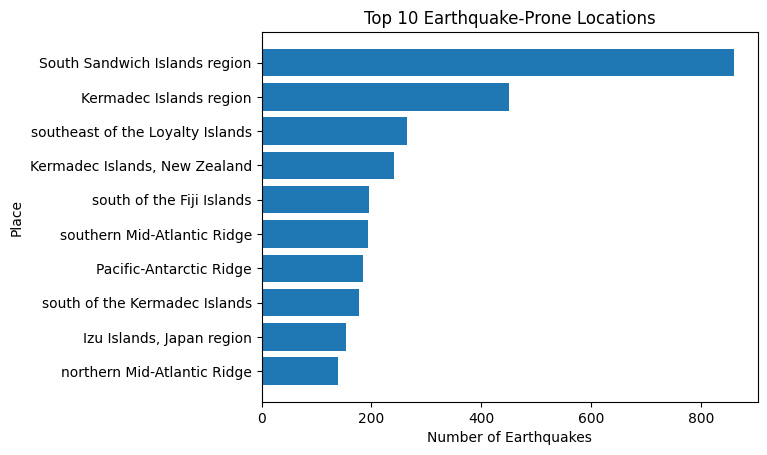

In [ ]:
#Top 10 Earthquake-Prone Places

top_places = df.groupBy("place") \
               .count() \
               .orderBy("count", ascending=False) \
               .limit(10) \
               .toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_places['place'], top_places['count'])
plt.xlabel("Number of Earthquakes")
plt.ylabel("Place")
plt.title("Top 10 Earthquake-Prone Locations")
plt.gca().invert_yaxis()
plt.show()

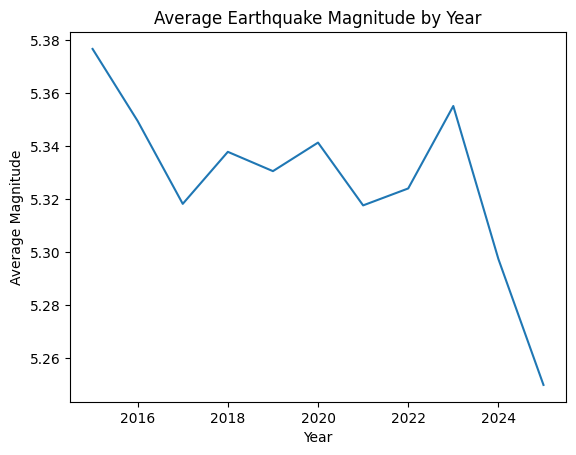

In [ ]:
#Average Magnitude by Year

avg_mag_year = df.groupBy("year") \
                 .avg("mag") \
                 .orderBy("year") \
                 .toPandas()

plt.figure()
plt.plot(avg_mag_year['year'], avg_mag_year['avg(mag)'])
plt.xlabel("Year")
plt.ylabel("Average Magnitude")
plt.title("Average Earthquake Magnitude by Year")
plt.show()

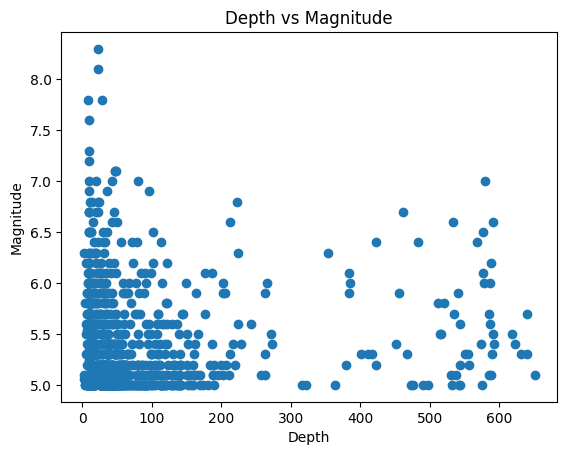

In [ ]:
#Depth vs Magnitude Scatter

sample_df = df.select("depth", "mag").sample(0.1).toPandas()

plt.figure()
plt.scatter(sample_df['depth'], sample_df['mag'])
plt.xlabel("Depth")
plt.ylabel("Magnitude")
plt.title("Depth vs Magnitude")
plt.show()

**📌 Key Insights**

Certain regions experience significantly higher earthquake frequency.

Average magnitude has remained relatively stable over the years.

Deeper earthquakes do not always mean stronger magnitude.

High-magnitude earthquakes are rare but geographically concentrated.

**This project demonstrates scalable big data processing using PySpark on global earthquake data. The analysis reveals patterns in earthquake frequency, magnitude distribution, and geographic concentration. Spark’s distributed computation capabilities allowed efficient processing of large-scale geospatial data.**

# New Section

🎯 TASK 2

Build a Machine Learning model to predict whether an earthquake will be Strong (Magnitude ≥ 5) or Normal (Magnitude < 5) based on historical seismic data.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
df = pd.read_csv("EarthquakeBigDataAnalysis.csv")
df.head()

,time,latitude,longitude,depth,mag,place,type
0,2025-03-03T15:40:36.720Z,12.6846,146.2399,10.000,5.1,"174 km ESE of Yigo Village, Guam",earthquake
1,2025-03-03T10:25:28.644Z,-16.7565,-177.3640,413.683,5.4,"282 km SSE of Alo, Wallis and Futuna",earthquake
2,2025-03-03T06:25:34.143Z,27.3373,61.0748,32.943,5.2,"41 km ENE of Iranshahr, Iran",earthquake
3,2025-03-02T18:42:09.427Z,-3.5151,129.4579,28.891,5.2,"59 km ESE of Masohi, Indonesia",earthquake
4,2025-03-02T14:16:58.339Z,-10.2343,66.0620,10.000,5.3,Mid-Indian Ridge,earthquake


In [24]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17014 entries, 0 to 17013
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   time       17014 non-null  object 
 1   latitude   17014 non-null  float64
 2   longitude  17014 non-null  float64
 3   depth      17014 non-null  float64
 4   mag        17014 non-null  float64
 5   place      17014 non-null  object 
 6   type       17014 non-null  object 
dtypes: float64(4), object(3)
memory usage: 930.6+ KB


,0
time,0
latitude,0
longitude,0
depth,0
mag,0
place,0
type,0


**Data Cleaning**

In [25]:
df = df.dropna(subset=['mag', 'depth', 'latitude', 'longitude'])

In [26]:
df['time'] = pd.to_datetime(df['time'])

In [27]:
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['hour'] = df['time'].dt.hour

In [28]:
df.head()

,time,latitude,longitude,depth,mag,place,type,year,month,hour
0,2025-03-03 15:40:36.720000+00:00,12.6846,146.2399,10.000,5.1,"174 km ESE of Yigo Village, Guam",earthquake,2025,3,15
1,2025-03-03 10:25:28.644000+00:00,-16.7565,-177.3640,413.683,5.4,"282 km SSE of Alo, Wallis and Futuna",earthquake,2025,3,10
2,2025-03-03 06:25:34.143000+00:00,27.3373,61.0748,32.943,5.2,"41 km ENE of Iranshahr, Iran",earthquake,2025,3,6
3,2025-03-02 18:42:09.427000+00:00,-3.5151,129.4579,28.891,5.2,"59 km ESE of Masohi, Indonesia",earthquake,2025,3,18
4,2025-03-02 14:16:58.339000+00:00,-10.2343,66.0620,10.000,5.3,Mid-Indian Ridge,earthquake,2025,3,14


**Earthquake Magnitude (Regression)**

In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features (exclude mag because it's target)
X = df[['depth', 'latitude', 'longitude', 'year', 'month', 'hour']]
y = df['mag']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.27906925196077587
RMSE: 0.3987181077099525
R2 Score: 0.08615364874076281


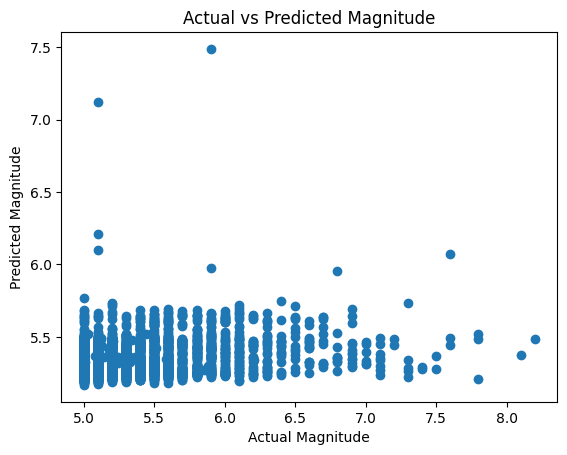

In [62]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Predicted Magnitude")
plt.show()

In [63]:
df['lat_long_interaction'] = df['latitude'] * df['longitude']

In [64]:
df['depth_squared'] = df['depth'] ** 2

In [65]:
df['log_depth'] = np.log1p(df['depth'])

In [66]:
X = df[['depth', 'log_depth', 'depth_squared',
        'latitude', 'longitude', 'lat_long_interaction',
        'year', 'month', 'hour']]

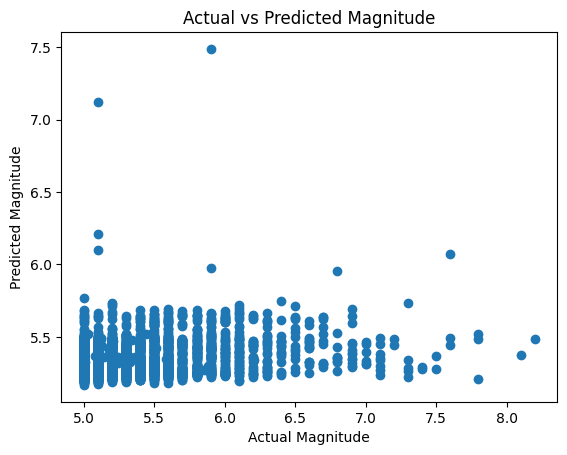

In [67]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Predicted Magnitude")
plt.show()

In [69]:
#Check Individual Predictions
y_pred = model.predict(X_test)

In [70]:
results = pd.DataFrame({
    "Actual_Magnitude": y_test.values,
    "Predicted_Magnitude": y_pred
})

results.head(10)

,Actual_Magnitude,Predicted_Magnitude
0,5.7,5.286990
1,5.0,5.299590
2,5.3,5.277297
3,5.1,5.243664
4,5.8,5.244686
5,5.2,5.429509
6,5.3,5.272809
7,5.1,5.396934
8,5.2,5.398477
9,5.4,5.511930


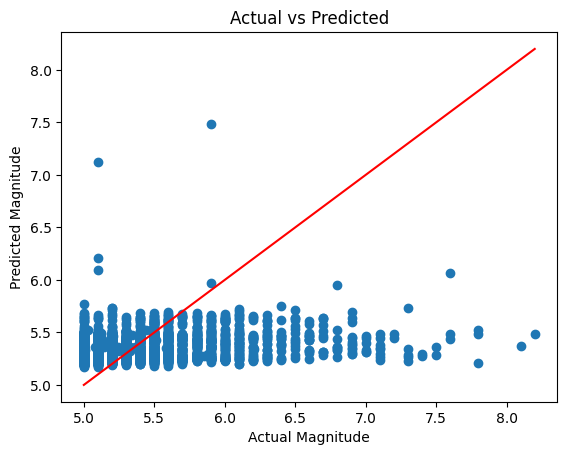

In [72]:
plt.figure()
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Predicted")
plt.show()

In [73]:

#Predict New Earthquake Manually

new_data = pd.DataFrame({
    'depth': [120],
    'latitude': [35.6],
    'longitude': [-120.5],
    'year': [2023],
    'month': [5],
    'hour': [14]
})

prediction = model.predict(new_data)
print("Predicted Magnitude:", prediction[0])

Predicted Magnitude: 5.404900420635045


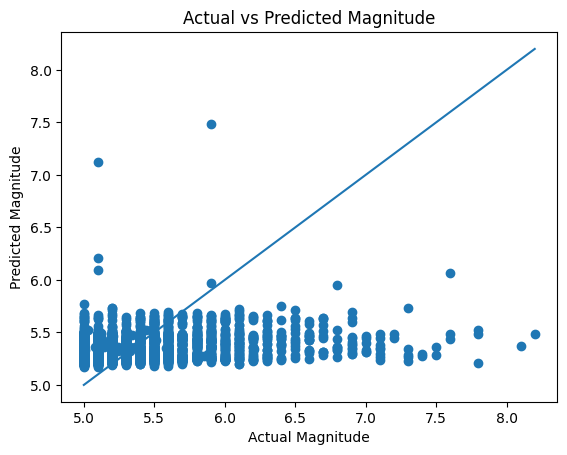

In [74]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])
plt.xlabel("Actual Magnitude")
plt.ylabel("Predicted Magnitude")
plt.title("Actual vs Predicted Magnitude")
plt.show()

 Results and Insights

- The model achieved an MAE of approximately 0.28 magnitude units.
- RMSE indicates moderate prediction deviation.
- The R² score shows limited explanatory power due to absence of geophysical variables.
- Earthquake magnitude is influenced by complex tectonic factors not included in the dataset.
- The model captures partial spatial-temporal patterns.

 Conclusion

This project developed a regression model to predict earthquake magnitude using spatial and temporal features. Although the model demonstrates moderate predictive capability, earthquake magnitude prediction remains inherently complex due to missing geological variables.

The project successfully demonstrates machine learning workflow including preprocessing, feature engineering, model training, and evaluation.